In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import importlib
import seaborn as sns

In [2]:
import set_paths
import src.preprocesing_tools as pt
import src.eda_tools as et

In [3]:
prep_data = pd.read_csv(r"..\data\preprocessed.csv")
stzd_data = (prep_data - prep_data.mean())/prep_data.std()
prep_data.head()

,Bankrupt?,ROA(C) before interest and depreciation before interest,ROA(A) before interest and % after tax,ROA(B) before interest and depreciation after tax,Operating Gross Margin,Realized Sales Gross Margin,Operating Profit Rate,Pre-tax net Interest Rate,After-tax net Interest Rate,Non-industry income and expenditure/revenue,...,Liability-Assets Flag,Net Income to Total Assets,Total assets to GNP price,No-credit Interval,Gross Profit to Sales,Net Income to Stockholder's Equity,Liability to Equity,Degree of Financial Leverage (DFL),Interest Coverage Ratio (Interest expense to EBIT),Equity to Liability
0,1,0.370594,0.424389,0.405750,0.601457,0.601457,0.998969,0.796887,0.808809,0.302646,...,0,0.716845,0.009219,0.622879,0.601453,0.827890,0.290202,0.026601,0.564050,0.016469
1,1,0.464291,0.538214,0.516730,0.610235,0.610235,0.998946,0.797380,0.809301,0.303556,...,0,0.795297,0.008323,0.623652,0.610237,0.839969,0.283846,0.264577,0.570175,0.020794
2,1,0.426071,0.499019,0.472295,0.601450,0.601364,0.998857,0.796403,0.808388,0.302035,...,0,0.774670,0.040003,0.623841,0.601449,0.836774,0.290189,0.026555,0.563706,0.016474
3,1,0.399844,0.451265,0.457733,0.583541,0.583541,0.998700,0.796967,0.808966,0.303350,...,0,0.739555,0.003252,0.622929,0.583538,0.834697,0.281721,0.026697,0.564663,0.023982
4,1,0.465022,0.538432,0.522298,0.598783,0.598783,0.998973,0.797366,0.809304,0.303475,...,0,0.795016,0.003878,0.623521,0.598782,0.839973,0.278514,0.024752,0.575617,0.035490


## Se observa un importante desbalance en el target, contando con un ratio de 30 a 1 (30 negativos por cada positivo)

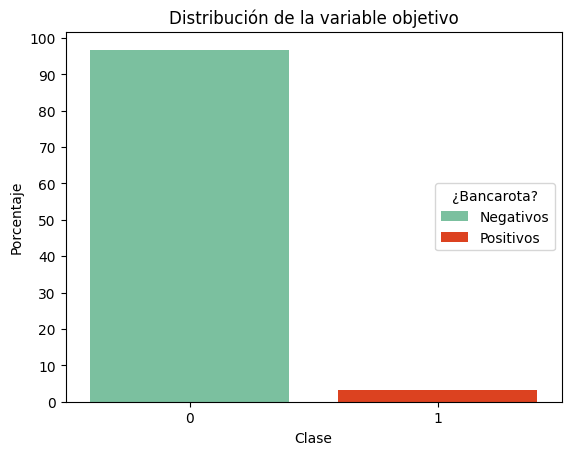

Ratio de positivos a negativos: 30:1


In [4]:
sns.countplot(data = prep_data, x = "Bankrupt?", 
              stat = "percent", hue = "Bankrupt?", palette = ["#6fcb9f", "#fb2e01"])
plt.title("Distribución de la variable objetivo")
plt.xlabel("Clase")
plt.ylabel("Porcentaje")
plt.legend(title = "¿Bancarota?", loc = "right", labels = ["Negativos", "Positivos"])
plt.yticks(range(0, 101, 10))
plt.show()

n_positive = prep_data["Bankrupt?"].sum()
n_negative = len(prep_data) - n_positive
ratio = n_negative / n_positive
print(f"Ratio de positivos a negativos: {int(np.round(ratio))}:1")

## Calculamos la matriz de correlación (Pearson) en busca de posibles redundancias entre feautures

<Axes: >

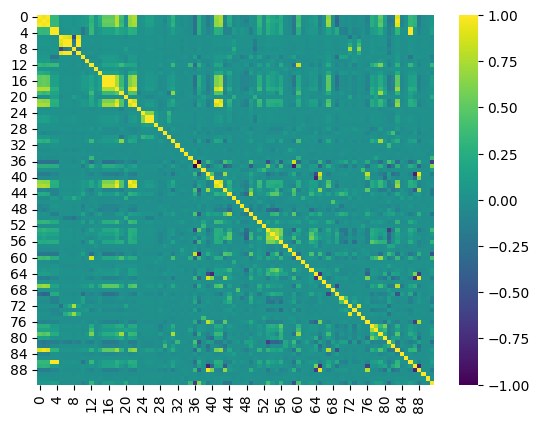

In [5]:
pcc_feautres_matrix = np.corrcoef(stzd_data.iloc[:, 1:].T.to_numpy())
sns.heatmap(pcc_feautres_matrix, cmap = "viridis")

Text(0, 0.5, 'Conteo')

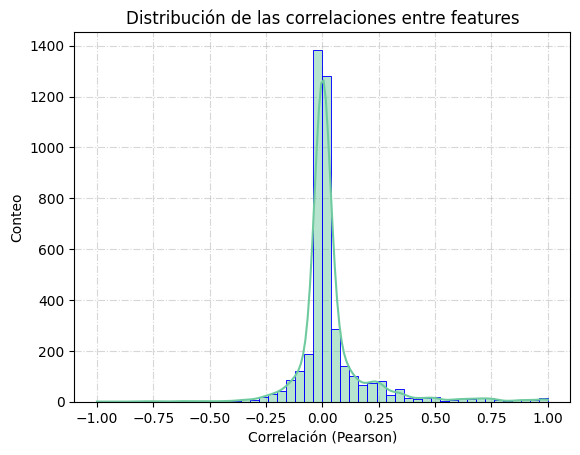

In [6]:
#No contamos las autocorrelaciones
ef_pcc_arr, ef_pcc_index = et.effective_correlations(pcc_feautres_matrix, diagonal = False, indices = True)
plt.title("Distribución de las correlaciones entre features")
plt.grid(linestyle = "dashdot", alpha = 0.5, zorder = 1)
sns.histplot(ef_pcc_arr, bins = 50,  stat = "count", zorder = 2, color = "#6fcb9f", edgecolor = "blue", kde = True)
plt.xlabel("Correlación (Pearson)")
plt.ylabel("Conteo")